## 6.1.2 损失函数与评价指标

本节在统一训练环境的基础上，构建后续 BaselineCNN 与 ResNet18Transfer 共用的损失函数和分类评价指标。

主要任务包括：

1. 读取 6.1.1 保存的统一训练环境配置；
2. 固定 EuroSAT RGB 的类别顺序与标签映射；
3. 配置多类别交叉熵损失函数；
4. 验证 PyTorch 交叉熵损失与理论计算结果的一致性；
5. 实现 Accuracy、Top-3 Accuracy、Precision、Recall 和 F1-score 等评价指标；
6. 构造确定性模拟输出，检查评价函数的计算正确性；
7. 生成混淆矩阵和指标对比可视化；
8. 保存后续模型训练可复用的统一评价配置。

本节仅验证损失函数和评价指标的实现，不使用未训练模型评价真实分类性能。

In [1]:
# ==========================================
# 6.1.2 基础导入、路径定位与结果目录
# ==========================================

# 必须在NumPy、PyTorch等库导入前设置
import os

# 兼容当前Windows + Conda环境中的OpenMP运行库
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 限制数值计算线程，避免OpenMP冲突
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# 延续6.1.1的确定性配置
os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8"
)

os.environ.setdefault(
    "PYTHONHASHSEED",
    "42"
)


import sys
import json
import math
import random
import platform
import warnings

from pathlib import Path
from datetime import datetime


import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)

from IPython.display import display


warnings.filterwarnings(
    "default"
)


# ------------------------------
# 限制PyTorch线程数量
# ------------------------------
torch.set_num_threads(
    1
)

try:
    torch.set_num_interop_threads(
        1
    )
except RuntimeError:
    # 重复运行Cell时可能无法再次修改
    pass


# ------------------------------
# 自动定位项目根目录
# ------------------------------
def find_project_root(
    start_path=None
):
    """
    从当前目录逐层向上搜索项目根目录。

    项目根目录应同时包含：
    1. EuroSAT_RGB
    2. models
    3. notebooks
    """

    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path).resolve()
    )

    candidate_paths = [
        current_path,
        *current_path.parents
    ]

    for candidate_path in candidate_paths:

        required_paths = [
            candidate_path / "EuroSAT_RGB",
            candidate_path / "models",
            candidate_path / "notebooks"
        ]

        if all(
            path.exists()
            for path in required_paths
        ):
            return candidate_path

    raise FileNotFoundError(
        "未能自动定位项目根目录。\n"
        "请确认项目根目录同时包含："
        "EuroSAT_RGB、models和notebooks。"
    )


PROJECT_ROOT = find_project_root()


# ------------------------------
# 项目固定目录
# ------------------------------
DATA_DIR = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

NOTEBOOKS_DIR = (
    PROJECT_ROOT
    / "notebooks"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


# ------------------------------
# 上一步配置目录
# ------------------------------
PREVIOUS_STEP_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.1_统一训练环境与随机性控制"
)

PREVIOUS_CONFIG_PATH = (
    PREVIOUS_STEP_DIR
    / "07_统一训练环境配置.json"
)


# ------------------------------
# 本步骤独立结果目录
# ------------------------------
STEP_OUTPUT_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.2_损失函数与评价指标"
)

STEP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------
# 中文字体配置
# ------------------------------
font_candidates = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans CN",
    "Arial Unicode MS"
]

available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

selected_font = next(
    (
        font_name
        for font_name in font_candidates
        if font_name in available_fonts
    ),
    None
)

if selected_font is not None:
    plt.rcParams[
        "font.sans-serif"
    ] = [
        selected_font
    ]

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300

plt.rcParams[
    "axes.titleweight"
] = "bold"

plt.rcParams[
    "axes.labelweight"
] = "bold"


# ------------------------------
# Pandas显示配置
# ------------------------------
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    180
)

pd.set_option(
    "display.max_colwidth",
    120
)


# ------------------------------
# 路径检查
# ------------------------------
directory_check_df = pd.DataFrame({
    "目录项目": [
        "项目根目录",
        "EuroSAT数据目录",
        "模型目录",
        "Notebook目录",
        "6.1.1结果目录",
        "6.1.1统一配置文件",
        "本步骤结果目录"
    ],
    "绝对路径": [
        str(PROJECT_ROOT),
        str(DATA_DIR),
        str(MODELS_DIR),
        str(NOTEBOOKS_DIR),
        str(PREVIOUS_STEP_DIR),
        str(PREVIOUS_CONFIG_PATH),
        str(STEP_OUTPUT_DIR)
    ],
    "是否存在": [
        PROJECT_ROOT.exists(),
        DATA_DIR.exists(),
        MODELS_DIR.exists(),
        NOTEBOOKS_DIR.exists(),
        PREVIOUS_STEP_DIR.exists(),
        PREVIOUS_CONFIG_PATH.exists(),
        STEP_OUTPUT_DIR.exists()
    ]
})


print(
    "6.1.2 项目路径定位完成。"
)

print(
    f"项目根目录：{PROJECT_ROOT}"
)

print(
    f"本步骤结果目录：{STEP_OUTPUT_DIR}"
)

if selected_font is not None:
    print(
        f"当前绘图中文字体：{selected_font}"
    )
else:
    print(
        "警告：未找到预设中文字体，"
        "图片中的中文可能无法正常显示。"
    )


display(
    directory_check_df
)


assert directory_check_df[
    "是否存在"
].all(), (
    "部分必要目录或6.1.1配置文件不存在，"
    "请检查项目结构。"
)

6.1.2 项目路径定位完成。
项目根目录：d:\qy\junior\深度学习\课设
本步骤结果目录：d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标
当前绘图中文字体：Microsoft YaHei


,目录项目,绝对路径,是否存在
0,项目根目录,d:\qy\junior\深度学习\课设,True
1,EuroSAT数据目录,d:\qy\junior\深度学习\课设\EuroSAT_RGB,True
2,模型目录,d:\qy\junior\深度学习\课设\models,True
3,Notebook目录,d:\qy\junior\深度学习\课设\notebooks,True
4,6.1.1结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制,True
5,6.1.1统一配置文件,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\07_统一训练环境配置.json,True
6,本步骤结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标,True


In [2]:
# ==========================================
# 6.1.2 读取统一环境配置并固定类别标签
# ==========================================

# ------------------------------
# 读取6.1.1统一配置
# ------------------------------
with open(
    PREVIOUS_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    runtime_config = json.load(
        file
    )


GLOBAL_SEED = int(
    runtime_config[
        "随机种子"
    ]
)

DEVICE = torch.device(
    runtime_config[
        "运行设备"
    ]
)


# ------------------------------
# 再次固定当前Notebook随机性
# ------------------------------
def seed_everything(
    seed
):
    """
    固定当前Notebook的主要随机数生成器。
    """

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


seed_everything(
    GLOBAL_SEED
)


# ------------------------------
# 固定EuroSAT类别顺序
# ------------------------------
CLASS_NAMES_EN = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]

CLASS_NAMES_CN = [
    "年生作物地",
    "永久性作物地",
    "森林",
    "草本植被",
    "牧场",
    "高速公路",
    "工业区",
    "居民区",
    "河流",
    "海洋与湖泊"
]

NUM_CLASSES = len(
    CLASS_NAMES_EN
)


CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name in enumerate(
        CLASS_NAMES_EN
    )
}

INDEX_TO_CLASS = {
    class_index: class_name
    for class_name, class_index in CLASS_TO_INDEX.items()
}

INDEX_TO_CHINESE = {
    class_index: chinese_name
    for class_index, chinese_name in enumerate(
        CLASS_NAMES_CN
    )
}


class_mapping_df = pd.DataFrame({
    "类别索引": list(
        range(NUM_CLASSES)
    ),
    "类别英文名称": CLASS_NAMES_EN,
    "类别中文名称": CLASS_NAMES_CN
})


class_mapping_path = (
    STEP_OUTPUT_DIR
    / "01_类别标签映射.csv"
)

class_mapping_df.to_csv(
    class_mapping_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "已读取6.1.1统一运行配置。"
)

print(
    f"全局随机种子：{GLOBAL_SEED}"
)

print(
    f"统一运行设备：{DEVICE}"
)

print(
    f"分类类别数量：{NUM_CLASSES}"
)

display(
    class_mapping_df
)


assert NUM_CLASSES == 10

assert list(
    CLASS_TO_INDEX.values()
) == list(
    range(NUM_CLASSES)
)

已读取6.1.1统一运行配置。
全局随机种子：42
统一运行设备：cpu
分类类别数量：10


,类别索引,类别英文名称,类别中文名称
0,0,AnnualCrop,年生作物地
1,1,PermanentCrop,永久性作物地
2,2,Forest,森林
3,3,HerbaceousVegetation,草本植被
4,4,Pasture,牧场
5,5,Highway,高速公路
6,6,Industrial,工业区
7,7,Residential,居民区
8,8,River,河流
9,9,SeaLake,海洋与湖泊


In [3]:
# ==========================================
# 6.1.2 交叉熵损失函数配置
# ==========================================

# ------------------------------
# 统一损失函数参数
# ------------------------------
LOSS_FUNCTION_NAME = (
    "CrossEntropyLoss"
)

LABEL_SMOOTHING = 0.0

LOSS_REDUCTION = "mean"

USE_CLASS_WEIGHTS = False


# 当前实验采用不加类别权重的交叉熵
CLASS_WEIGHT_TENSOR = None


criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHT_TENSOR,
    reduction=LOSS_REDUCTION,
    label_smoothing=LABEL_SMOOTHING
)


# ------------------------------
# 理论随机猜测损失
# ------------------------------
random_guess_probability = (
    1.0
    / NUM_CLASSES
)

random_guess_cross_entropy = (
    -math.log(
        random_guess_probability
    )
)


loss_config = {
    "损失函数": LOSS_FUNCTION_NAME,
    "类别数量": NUM_CLASSES,
    "归约方式": LOSS_REDUCTION,
    "标签平滑系数": LABEL_SMOOTHING,
    "是否使用类别权重": USE_CLASS_WEIGHTS,
    "类别权重": (
        None
        if CLASS_WEIGHT_TENSOR is None
        else CLASS_WEIGHT_TENSOR.tolist()
    ),
    "随机猜测正确类别概率": (
        random_guess_probability
    ),
    "均匀随机猜测理论交叉熵": (
        random_guess_cross_entropy
    ),
    "主要模型选择指标": (
        "验证集Macro-F1"
    ),
    "辅助模型选择指标": [
        "验证集Accuracy",
        "验证集Loss"
    ]
}


loss_config_path = (
    STEP_OUTPUT_DIR
    / "02_损失函数与评价指标配置.json"
)

with open(
    loss_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        loss_config,
        file,
        ensure_ascii=False,
        indent=4
    )


loss_config_df = pd.DataFrame({
    "配置项目": [
        "损失函数",
        "类别数量",
        "归约方式",
        "标签平滑系数",
        "是否使用类别权重",
        "均匀随机猜测理论损失",
        "主要模型选择指标",
        "辅助模型选择指标"
    ],
    "配置结果": [
        LOSS_FUNCTION_NAME,
        NUM_CLASSES,
        LOSS_REDUCTION,
        LABEL_SMOOTHING,
        USE_CLASS_WEIGHTS,
        round(
            random_guess_cross_entropy,
            6
        ),
        "验证集Macro-F1",
        "Accuracy与Loss"
    ]
})


print(
    "统一损失函数配置："
)

display(
    loss_config_df
)

print(
    f"\n均匀随机猜测的理论交叉熵："
    f"{random_guess_cross_entropy:.6f}"
)

print(
    f"配置文件已保存："
    f"{loss_config_path.name}"
)

统一损失函数配置：


,配置项目,配置结果
0,损失函数,CrossEntropyLoss
1,类别数量,10
2,归约方式,mean
3,标签平滑系数,0.0
4,是否使用类别权重,False
5,均匀随机猜测理论损失,2.302585
6,主要模型选择指标,验证集Macro-F1
7,辅助模型选择指标,Accuracy与Loss



均匀随机猜测的理论交叉熵：2.302585
配置文件已保存：02_损失函数与评价指标配置.json


#### 损失函数配置与理论等价性分析

本实验将 EuroSAT RGB 数据集的 10 个土地利用类别依次映射为索引 0～9，并在后续两个候选模型中统一使用这一类别顺序。固定类别索引能够保证模型输出位置、真实标签、类别评价指标和混淆矩阵坐标之间保持一致，避免不同 Notebook 或模型之间出现标签顺序错位。

分类任务采用多类别交叉熵损失函数 `CrossEntropyLoss`，归约方式设置为 `mean`，即先计算一个批次内每个样本的交叉熵，再取批次平均值作为优化目标。当前标签平滑系数为 0，未使用额外类别权重，因此本节建立的是标准、无附加修正的交叉熵训练基线。前序数据分层划分已经在训练集、验证集和测试集中保持原始类别结构，本实验又将 Macro-F1 设为主要模型选择指标，因此暂不添加类别权重是合理的；后续若发现少样本类别的召回率明显偏低，再考虑加入加权交叉熵或其他类别均衡策略。

对于 10 分类问题，在模型对所有类别给出相同概率时，真实类别预测概率为

[
p_y=\frac{1}{10}=0.1
]

对应的理论交叉熵为

[
L=-\log(p_y)=-\log(0.1)=\log(10)\approx2.302585
]

因此，2.302585 可以作为模型训练初期的重要参考值。若模型输出近似均匀分布，其平均损失通常接近该数值；随着模型逐渐学习到有效分类特征，训练集和验证集损失应总体下降至这一参考值以下。

理论等价性检查中，给定 logits 为 `[2.0, 1.0, 0.0]`、真实类别为第 0 类时，PyTorch `CrossEntropyLoss` 计算结果为 0.407606。使用 Softmax 后手动计算 (-\log(p_y)) 得到相同结果，使用 `LogSoftmax + NLLLoss` 也得到 0.407606。手动计算与 PyTorch 结果的绝对差异仅为 (2.98\times10^{-8})，属于 `float32` 浮点数运算产生的正常舍入误差，而非计算逻辑错误。

由此说明，本实验的交叉熵损失函数配置、类别索引和理论计算关系均正确，可以直接用于后续 BaselineCNN 与 ResNet18Transfer 的统一训练。


In [4]:
# ==========================================
# 6.1.2 交叉熵理论等价性检查
# ==========================================

# 构造一个三分类样本
example_logits = torch.tensor(
    [
        [
            2.0,
            1.0,
            0.0
        ]
    ],
    dtype=torch.float32
)

example_target = torch.tensor(
    [
        0
    ],
    dtype=torch.long
)


# ------------------------------
# PyTorch交叉熵计算
# ------------------------------
torch_cross_entropy = (
    nn.CrossEntropyLoss()(
        example_logits,
        example_target
    )
)


# ------------------------------
# 手动计算Softmax概率
# ------------------------------
example_probability = F.softmax(
    example_logits,
    dim=1
)

true_class_probability = (
    example_probability[
        0,
        example_target.item()
    ]
)

manual_cross_entropy = (
    -torch.log(
        true_class_probability
    )
)


# ------------------------------
# 通过LogSoftmax + NLLLoss计算
# ------------------------------
log_probability = F.log_softmax(
    example_logits,
    dim=1
)

nll_cross_entropy = F.nll_loss(
    log_probability,
    example_target
)


absolute_difference_manual = float(
    torch.abs(
        torch_cross_entropy
        - manual_cross_entropy
    )
)

absolute_difference_nll = float(
    torch.abs(
        torch_cross_entropy
        - nll_cross_entropy
    )
)


loss_equivalence_df = pd.DataFrame({
    "计算方法": [
        "PyTorch CrossEntropyLoss",
        "手动计算 -log(p_y)",
        "LogSoftmax + NLLLoss"
    ],
    "损失值": [
        float(
            torch_cross_entropy
        ),
        float(
            manual_cross_entropy
        ),
        float(
            nll_cross_entropy
        )
    ],
    "与CrossEntropyLoss绝对差异": [
        0.0,
        absolute_difference_manual,
        absolute_difference_nll
    ]
})


loss_equivalence_path = (
    STEP_OUTPUT_DIR
    / "03_交叉熵理论等价性检查.csv"
)

loss_equivalence_df.to_csv(
    loss_equivalence_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "交叉熵损失理论等价性检查："
)

display(
    loss_equivalence_df
)


assert absolute_difference_manual < 1e-7

assert absolute_difference_nll < 1e-7


print(
    "\n检查结论：CrossEntropyLoss、"
    "-log(p_y)和LogSoftmax + NLLLoss"
    "三种计算结果一致。"
)

交叉熵损失理论等价性检查：


,计算方法,损失值,与CrossEntropyLoss绝对差异
0,PyTorch CrossEntropyLoss,0.407606,0.000000e+00
1,手动计算 -log(p_y),0.407606,2.980232e-08
2,LogSoftmax + NLLLoss,0.407606,0.000000e+00



检查结论：CrossEntropyLoss、-log(p_y)和LogSoftmax + NLLLoss三种计算结果一致。


In [5]:
# ==========================================
# 6.1.2 统一多分类评价函数
# ==========================================

def calculate_top_k_accuracy(
    probabilities,
    targets,
    top_k=3
):
    """
    计算Top-k准确率。

    参数
    ----------
    probabilities:
        形状为[N, C]的类别概率张量。
    targets:
        形状为[N]的真实标签张量。
    top_k:
        统计前k个预测中是否包含真实标签。
    """

    top_k = min(
        top_k,
        probabilities.shape[1]
    )

    top_indices = torch.topk(
        probabilities,
        k=top_k,
        dim=1
    ).indices

    targets_expanded = (
        targets
        .view(-1, 1)
        .expand_as(
            top_indices
        )
    )

    correct_mask = (
        top_indices
        == targets_expanded
    )

    return float(
        correct_mask
        .any(dim=1)
        .float()
        .mean()
    )


def evaluate_classification_logits(
    logits,
    targets,
    class_names_en=CLASS_NAMES_EN,
    class_names_cn=CLASS_NAMES_CN,
    criterion_object=criterion
):
    """
    根据模型logits和真实标签计算统一评价指标。

    返回
    ----------
    summary_metrics:
        总体评价指标字典。
    class_metrics_df:
        各类别Precision、Recall、F1和Support。
    confusion_matrix_array:
        原始计数混淆矩阵。
    normalized_confusion_matrix:
        按真实类别归一化的混淆矩阵。
    predictions:
        Top-1预测标签。
    probabilities:
        Softmax类别概率。
    """

    if not isinstance(
        logits,
        torch.Tensor
    ):
        logits = torch.tensor(
            logits,
            dtype=torch.float32
        )

    if not isinstance(
        targets,
        torch.Tensor
    ):
        targets = torch.tensor(
            targets,
            dtype=torch.long
        )

    logits = (
        logits
        .detach()
        .cpu()
        .float()
    )

    targets = (
        targets
        .detach()
        .cpu()
        .long()
    )

    if logits.ndim != 2:
        raise ValueError(
            "logits必须是形状为[N, C]的二维张量。"
        )

    if targets.ndim != 1:
        raise ValueError(
            "targets必须是形状为[N]的一维张量。"
        )

    if logits.shape[0] != targets.shape[0]:
        raise ValueError(
            "logits与targets的样本数量不一致。"
        )

    if logits.shape[1] != len(
        class_names_en
    ):
        raise ValueError(
            "logits的类别维度与类别名称数量不一致。"
        )

    if torch.isnan(
        logits
    ).any():
        raise ValueError(
            "logits中存在NaN。"
        )

    if torch.isinf(
        logits
    ).any():
        raise ValueError(
            "logits中存在Inf。"
        )


    # ------------------------------
    # 损失、概率与Top-1预测
    # ------------------------------
    loss_value = float(
        criterion_object(
            logits,
            targets
        )
    )

    probabilities = F.softmax(
        logits,
        dim=1
    )

    predictions = torch.argmax(
        probabilities,
        dim=1
    )


    y_true = targets.numpy()

    y_pred = predictions.numpy()


    # ------------------------------
    # 总体指标
    # ------------------------------
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    top3_accuracy = calculate_top_k_accuracy(
        probabilities,
        targets,
        top_k=3
    )


    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(
                range(
                    len(
                        class_names_en
                    )
                )
            ),
            average="macro",
            zero_division=0
        )
    )


    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(
                range(
                    len(
                        class_names_en
                    )
                )
            ),
            average="weighted",
            zero_division=0
        )
    )


    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )


    # ------------------------------
    # 各类别指标
    # ------------------------------
    (
        class_precision,
        class_recall,
        class_f1,
        class_support
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(
            range(
                len(
                    class_names_en
                )
            )
        ),
        average=None,
        zero_division=0
    )


    class_metrics_df = pd.DataFrame({
        "类别索引": list(
            range(
                len(
                    class_names_en
                )
            )
        ),
        "类别中文名称": class_names_cn,
        "类别英文名称": class_names_en,
        "Precision": class_precision,
        "Recall": class_recall,
        "F1-score": class_f1,
        "Support": class_support.astype(
            int
        )
    })


    # ------------------------------
    # 混淆矩阵
    # ------------------------------
    class_labels = list(
        range(
            len(
                class_names_en
            )
        )
    )

    confusion_matrix_array = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    row_sums = (
        confusion_matrix_array
        .sum(
            axis=1,
            keepdims=True
        )
    )

    normalized_confusion_matrix = np.divide(
        confusion_matrix_array,
        row_sums,
        out=np.zeros_like(
            confusion_matrix_array,
            dtype=np.float64
        ),
        where=row_sums != 0
    )


    summary_metrics = {
        "样本数量": int(
            len(
                y_true
            )
        ),
        "交叉熵损失": loss_value,
        "Top-1 Accuracy": float(
            accuracy
        ),
        "Top-3 Accuracy": float(
            top3_accuracy
        ),
        "Balanced Accuracy": float(
            balanced_accuracy
        ),
        "Macro Precision": float(
            macro_precision
        ),
        "Macro Recall": float(
            macro_recall
        ),
        "Macro F1": float(
            macro_f1
        ),
        "Weighted Precision": float(
            weighted_precision
        ),
        "Weighted Recall": float(
            weighted_recall
        ),
        "Weighted F1": float(
            weighted_f1
        ),
        "Cohen Kappa": float(
            kappa
        ),
        "Matthews相关系数": float(
            mcc
        )
    }


    return (
        summary_metrics,
        class_metrics_df,
        confusion_matrix_array,
        normalized_confusion_matrix,
        predictions,
        probabilities
    )


print(
    "统一多分类评价函数定义完成。"
)

print(
    "主要评价指标："
    "Loss、Top-1 Accuracy、Top-3 Accuracy、"
    "Macro-F1、Weighted-F1、Kappa和MCC。"
)

统一多分类评价函数定义完成。
主要评价指标：Loss、Top-1 Accuracy、Top-3 Accuracy、Macro-F1、Weighted-F1、Kappa和MCC。


In [6]:
# ==========================================
# 6.1.2 构造确定性模拟案例并验证指标
# ==========================================

SAMPLES_PER_CLASS = 10

TOTAL_SYNTHETIC_SAMPLES = (
    NUM_CLASSES
    * SAMPLES_PER_CLASS
)


# 每个类别包含10个样本
synthetic_targets = torch.tensor(
    np.repeat(
        np.arange(
            NUM_CLASSES
        ),
        SAMPLES_PER_CLASS
    ),
    dtype=torch.long
)


def build_perfect_logits(
    targets,
    num_classes
):
    """
    构造全部预测正确的logits。
    """

    logits = torch.full(
        (
            len(targets),
            num_classes
        ),
        fill_value=-4.0,
        dtype=torch.float32
    )

    logits[
        torch.arange(
            len(targets)
        ),
        targets
    ] = 6.0

    return logits


def build_partial_logits(
    targets,
    num_classes,
    correct_per_class=7
):
    """
    每类固定7个样本预测正确，
    其余样本预测为相邻类别。

    错误样本的真实类别保留为第二高分，
    因而可用于同时验证Top-1和Top-3指标。
    """

    logits = torch.full(
        (
            len(targets),
            num_classes
        ),
        fill_value=-4.0,
        dtype=torch.float32
    )

    for sample_index, target in enumerate(
        targets.tolist()
    ):

        position_in_class = (
            sample_index
            % SAMPLES_PER_CLASS
        )

        if position_in_class < correct_per_class:

            predicted_class = target

            logits[
                sample_index,
                target
            ] = 5.0

        else:

            predicted_class = (
                target + 1
            ) % num_classes

            logits[
                sample_index,
                predicted_class
            ] = 5.0

            logits[
                sample_index,
                target
            ] = 3.0

    return logits


def build_single_class_logits(
    targets,
    num_classes,
    predicted_class=0
):
    """
    构造全部预测为同一类别的logits。
    """

    logits = torch.full(
        (
            len(targets),
            num_classes
        ),
        fill_value=-3.0,
        dtype=torch.float32
    )

    logits[
        :,
        predicted_class
    ] = 4.0

    return logits


synthetic_cases = {
    "完全正确案例": build_perfect_logits(
        synthetic_targets,
        NUM_CLASSES
    ),
    "部分正确案例": build_partial_logits(
        synthetic_targets,
        NUM_CLASSES,
        correct_per_class=7
    ),
    "单类别偏置案例": build_single_class_logits(
        synthetic_targets,
        NUM_CLASSES,
        predicted_class=0
    )
}


case_summary_records = []

case_class_metric_frames = []

case_results = {}


for case_name, case_logits in synthetic_cases.items():

    (
        summary_metrics,
        class_metrics_df,
        raw_confusion_matrix,
        normalized_confusion_matrix,
        predictions,
        probabilities
    ) = evaluate_classification_logits(
        logits=case_logits,
        targets=synthetic_targets
    )

    summary_record = {
        "模拟案例": case_name,
        **summary_metrics
    }

    case_summary_records.append(
        summary_record
    )

    case_class_df = (
        class_metrics_df
        .copy()
    )

    case_class_df.insert(
        0,
        "模拟案例",
        case_name
    )

    case_class_metric_frames.append(
        case_class_df
    )

    case_results[
        case_name
    ] = {
        "summary_metrics": summary_metrics,
        "class_metrics_df": (
            class_metrics_df
        ),
        "raw_confusion_matrix": (
            raw_confusion_matrix
        ),
        "normalized_confusion_matrix": (
            normalized_confusion_matrix
        ),
        "predictions": predictions,
        "probabilities": probabilities
    }


synthetic_summary_df = pd.DataFrame(
    case_summary_records
)

synthetic_class_metrics_df = pd.concat(
    case_class_metric_frames,
    ignore_index=True
)


# ------------------------------
# 保存结果
# ------------------------------
synthetic_summary_path = (
    STEP_OUTPUT_DIR
    / "04_模拟案例总体指标.csv"
)

synthetic_summary_df.to_csv(
    synthetic_summary_path,
    index=False,
    encoding="utf-8-sig"
)


synthetic_class_metrics_path = (
    STEP_OUTPUT_DIR
    / "05_模拟案例类别指标.csv"
)

synthetic_class_metrics_df.to_csv(
    synthetic_class_metrics_path,
    index=False,
    encoding="utf-8-sig"
)


partial_confusion_df = pd.DataFrame(
    case_results[
        "部分正确案例"
    ][
        "raw_confusion_matrix"
    ],
    index=[
        f"{cn}\n{en}"
        for cn, en in zip(
            CLASS_NAMES_CN,
            CLASS_NAMES_EN
        )
    ],
    columns=[
        f"{cn}\n{en}"
        for cn, en in zip(
            CLASS_NAMES_CN,
            CLASS_NAMES_EN
        )
    ]
)

partial_confusion_path = (
    STEP_OUTPUT_DIR
    / "06_部分正确案例混淆矩阵.csv"
)

partial_confusion_df.to_csv(
    partial_confusion_path,
    encoding="utf-8-sig"
)


print(
    "确定性模拟案例总体评价结果："
)

display(
    synthetic_summary_df
)


print(
    "\n部分正确案例混淆矩阵："
)

display(
    partial_confusion_df
)

确定性模拟案例总体评价结果：


,模拟案例,样本数量,交叉熵损失,Top-1 Accuracy,Top-3 Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Cohen Kappa,Matthews相关系数
0,完全正确案例,100,0.000409,1.0,1.0,1.0,1.00,1.0,1.000000,1.00,1.0,1.000000,1.000000,1.000000
1,部分正确案例,100,0.639116,0.7,1.0,0.7,0.70,0.7,0.700000,0.70,0.7,0.700000,0.666667,0.666667
2,单类别偏置案例,100,6.308172,0.1,0.3,0.1,0.01,0.1,0.018182,0.01,0.1,0.018182,0.000000,0.000000



部分正确案例混淆矩阵：


,年生作物地\nAnnualCrop,永久性作物地\nPermanentCrop,森林\nForest,草本植被\nHerbaceousVegetation,牧场\nPasture,高速公路\nHighway,工业区\nIndustrial,居民区\nResidential,河流\nRiver,海洋与湖泊\nSeaLake
年生作物地\nAnnualCrop,7,3,0,0,0,0,0,0,0,0
永久性作物地\nPermanentCrop,0,7,3,0,0,0,0,0,0,0
森林\nForest,0,0,7,3,0,0,0,0,0,0
草本植被\nHerbaceousVegetation,0,0,0,7,3,0,0,0,0,0
牧场\nPasture,0,0,0,0,7,3,0,0,0,0
高速公路\nHighway,0,0,0,0,0,7,3,0,0,0
工业区\nIndustrial,0,0,0,0,0,0,7,3,0,0
居民区\nResidential,0,0,0,0,0,0,0,7,3,0
河流\nRiver,0,0,0,0,0,0,0,0,7,3
海洋与湖泊\nSeaLake,3,0,0,0,0,0,0,0,0,7


In [7]:
# ==========================================
# 6.1.2 评价指标实现完整性检查
# ==========================================

perfect_row = (
    synthetic_summary_df[
        synthetic_summary_df[
            "模拟案例"
        ] == "完全正确案例"
    ]
    .iloc[0]
)

partial_row = (
    synthetic_summary_df[
        synthetic_summary_df[
            "模拟案例"
        ] == "部分正确案例"
    ]
    .iloc[0]
)

biased_row = (
    synthetic_summary_df[
        synthetic_summary_df[
            "模拟案例"
        ] == "单类别偏置案例"
    ]
    .iloc[0]
)


# ------------------------------
# 预期结果
# ------------------------------
expected_partial_accuracy = 0.70

expected_biased_accuracy = (
    1.0
    / NUM_CLASSES
)


metric_integrity_records = [
    {
        "检查项目": "损失函数对象",
        "检查结果": type(
            criterion
        ).__name__,
        "是否通过": isinstance(
            criterion,
            nn.CrossEntropyLoss
        )
    },
    {
        "检查项目": "完全正确案例Top-1准确率",
        "检查结果": (
            f"{perfect_row['Top-1 Accuracy']:.6f}"
        ),
        "是否通过": np.isclose(
            perfect_row[
                "Top-1 Accuracy"
            ],
            1.0
        )
    },
    {
        "检查项目": "完全正确案例Macro-F1",
        "检查结果": (
            f"{perfect_row['Macro F1']:.6f}"
        ),
        "是否通过": np.isclose(
            perfect_row[
                "Macro F1"
            ],
            1.0
        )
    },
    {
        "检查项目": "部分正确案例Top-1准确率",
        "检查结果": (
            f"{partial_row['Top-1 Accuracy']:.6f}"
        ),
        "是否通过": np.isclose(
            partial_row[
                "Top-1 Accuracy"
            ],
            expected_partial_accuracy
        )
    },
    {
        "检查项目": "部分正确案例Top-3准确率",
        "检查结果": (
            f"{partial_row['Top-3 Accuracy']:.6f}"
        ),
        "是否通过": np.isclose(
            partial_row[
                "Top-3 Accuracy"
            ],
            1.0
        )
    },
    {
        "检查项目": "单类别偏置案例Top-1准确率",
        "检查结果": (
            f"{biased_row['Top-1 Accuracy']:.6f}"
        ),
        "是否通过": np.isclose(
            biased_row[
                "Top-1 Accuracy"
            ],
            expected_biased_accuracy
        )
    },
    {
        "检查项目": "混淆矩阵尺寸",
        "检查结果": str(
            case_results[
                "部分正确案例"
            ][
                "raw_confusion_matrix"
            ].shape
        ),
        "是否通过": (
            case_results[
                "部分正确案例"
            ][
                "raw_confusion_matrix"
            ].shape
            == (
                NUM_CLASSES,
                NUM_CLASSES
            )
        )
    },
    {
        "检查项目": "混淆矩阵样本总数",
        "检查结果": int(
            case_results[
                "部分正确案例"
            ][
                "raw_confusion_matrix"
            ].sum()
        ),
        "是否通过": (
            int(
                case_results[
                    "部分正确案例"
                ][
                    "raw_confusion_matrix"
                ].sum()
            )
            == TOTAL_SYNTHETIC_SAMPLES
        )
    },
    {
        "检查项目": "总体指标是否存在NaN",
        "检查结果": (
            "未发现"
            if not synthetic_summary_df[
                [
                    "交叉熵损失",
                    "Top-1 Accuracy",
                    "Top-3 Accuracy",
                    "Macro F1",
                    "Weighted F1"
                ]
            ].isna().any().any()
            else "发现NaN"
        ),
        "是否通过": not synthetic_summary_df[
            [
                "交叉熵损失",
                "Top-1 Accuracy",
                "Top-3 Accuracy",
                "Macro F1",
                "Weighted F1"
            ]
        ].isna().any().any()
    }
]


metric_integrity_df = pd.DataFrame(
    metric_integrity_records
)


metric_integrity_path = (
    STEP_OUTPUT_DIR
    / "07_评价指标完整性检查.csv"
)

metric_integrity_df.to_csv(
    metric_integrity_path,
    index=False,
    encoding="utf-8-sig"
)


all_metric_checks_passed = bool(
    metric_integrity_df[
        "是否通过"
    ].all()
)


print(
    "评价指标实现完整性检查："
)

display(
    metric_integrity_df
)


assert all_metric_checks_passed, (
    "评价指标完整性检查未全部通过，"
    "请检查损失函数或指标实现。"
)


print(
    "\n检查结论：损失函数、Top-1、Top-3、"
    "Macro-F1和混淆矩阵计算均符合预期。"
)

评价指标实现完整性检查：


,检查项目,检查结果,是否通过
0,损失函数对象,CrossEntropyLoss,True
1,完全正确案例Top-1准确率,1.000000,True
2,完全正确案例Macro-F1,1.000000,True
3,部分正确案例Top-1准确率,0.700000,True
4,部分正确案例Top-3准确率,1.000000,True
5,单类别偏置案例Top-1准确率,0.100000,True
6,混淆矩阵尺寸,"(10, 10)",True
7,混淆矩阵样本总数,100,True
8,总体指标是否存在NaN,未发现,True



检查结论：损失函数、Top-1、Top-3、Macro-F1和混淆矩阵计算均符合预期。


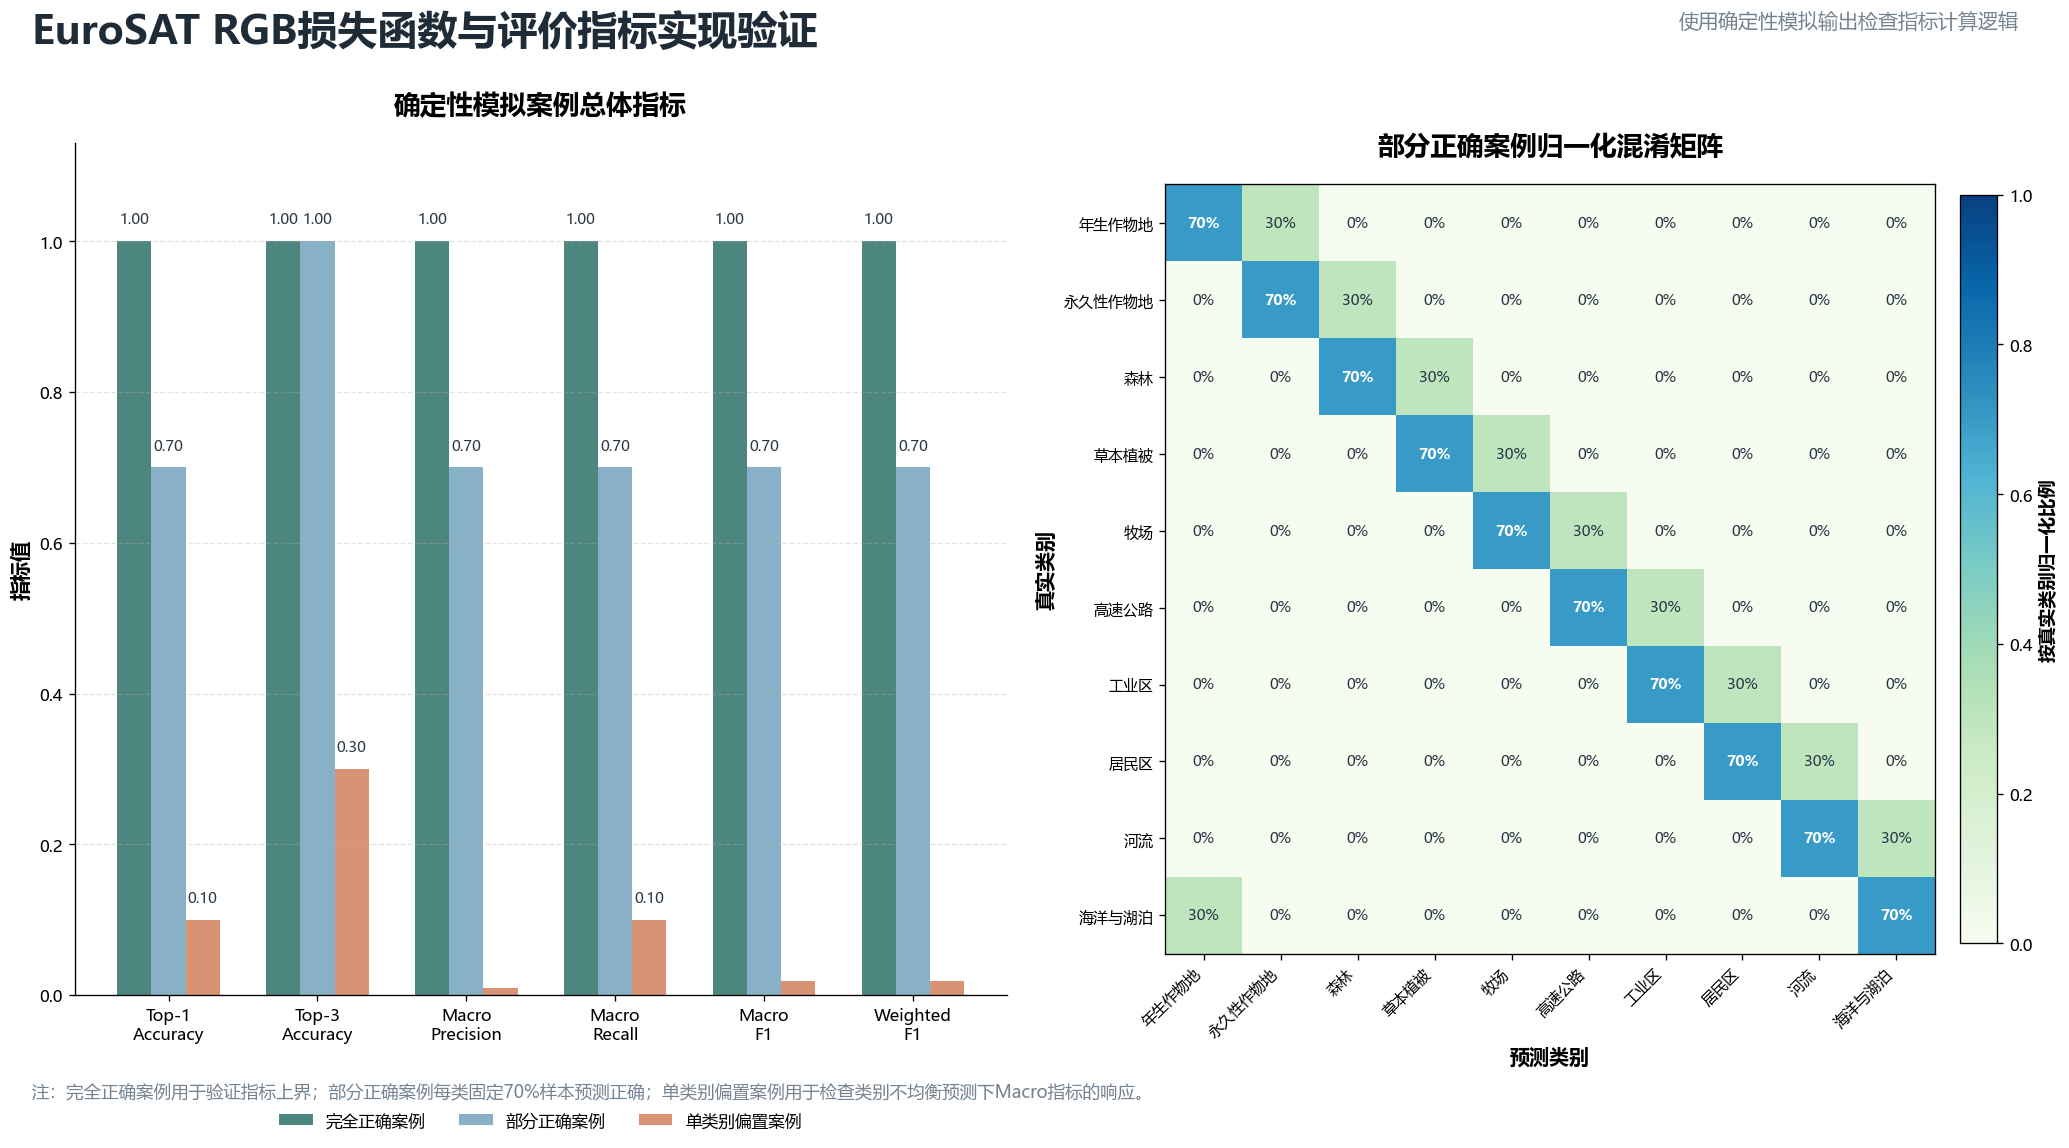

指标验证图已保存：08_模拟案例指标与混淆矩阵.png


In [8]:
# ==========================================
# 6.1.2 模拟案例指标与混淆矩阵可视化
# ==========================================

plot_metric_names = [
    "Top-1 Accuracy",
    "Top-3 Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

plot_metric_labels = [
    "Top-1\nAccuracy",
    "Top-3\nAccuracy",
    "Macro\nPrecision",
    "Macro\nRecall",
    "Macro\nF1",
    "Weighted\nF1"
]

case_names = synthetic_summary_df[
    "模拟案例"
].tolist()

case_colors = [
    "#3E7C73",
    "#7EAAC3",
    "#D58A68"
]


fig = plt.figure(
    figsize=(18, 10)
)

grid_spec = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[
        1.12,
        1.0
    ],
    left=0.06,
    right=0.95,
    top=0.84,
    bottom=0.13,
    wspace=0.18
)

ax_metrics = fig.add_subplot(
    grid_spec[0, 0]
)

ax_confusion = fig.add_subplot(
    grid_spec[0, 1]
)


# ------------------------------
# 总标题与副标题
# ------------------------------
fig.text(
    0.04,
    0.95,
    "EuroSAT RGB损失函数与评价指标实现验证",
    fontsize=24,
    fontweight="bold",
    color="#1F2B36",
    va="top"
)

fig.text(
    0.96,
    0.95,
    "使用确定性模拟输出检查指标计算逻辑",
    fontsize=12,
    color="#748391",
    ha="right",
    va="top"
)


# ------------------------------
# 左侧：三个案例指标对比
# ------------------------------
x_positions = np.arange(
    len(
        plot_metric_names
    )
)

bar_width = 0.23


for case_index, case_name in enumerate(
    case_names
):

    case_row = (
        synthetic_summary_df[
            synthetic_summary_df[
                "模拟案例"
            ] == case_name
        ]
        .iloc[0]
    )

    metric_values = [
        float(
            case_row[
                metric_name
            ]
        )
        for metric_name in plot_metric_names
    ]

    bar_positions = (
        x_positions
        + (
            case_index - 1
        ) * bar_width
    )

    bars = ax_metrics.bar(
        bar_positions,
        metric_values,
        width=bar_width,
        label=case_name,
        color=case_colors[
            case_index
        ],
        alpha=0.92
    )

    for bar, metric_value in zip(
        bars,
        metric_values
    ):

        if metric_value < 0.035:
            continue

        ax_metrics.text(
            bar.get_x()
            + bar.get_width() / 2,
            metric_value + 0.018,
            f"{metric_value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#283642"
        )


ax_metrics.set_title(
    "确定性模拟案例总体指标",
    fontsize=16,
    pad=18
)

ax_metrics.set_xticks(
    x_positions
)

ax_metrics.set_xticklabels(
    plot_metric_labels,
    fontsize=10
)

ax_metrics.set_ylabel(
    "指标值",
    fontsize=12
)

ax_metrics.set_ylim(
    0,
    1.13
)

ax_metrics.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax_metrics.spines[
    "top"
].set_visible(
    False
)

ax_metrics.spines[
    "right"
].set_visible(
    False
)

ax_metrics.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.12
    ),
    ncol=3,
    frameon=False,
    fontsize=10
)


# ------------------------------
# 右侧：部分正确案例混淆矩阵
# ------------------------------
normalized_matrix = (
    case_results[
        "部分正确案例"
    ][
        "normalized_confusion_matrix"
    ]
)

image = ax_confusion.imshow(
    normalized_matrix,
    cmap="GnBu",
    vmin=0,
    vmax=1
)


for row_index in range(
    NUM_CLASSES
):

    for column_index in range(
        NUM_CLASSES
    ):

        cell_value = normalized_matrix[
            row_index,
            column_index
        ]

        text_color = (
            "white"
            if cell_value >= 0.55
            else "#263542"
        )

        ax_confusion.text(
            column_index,
            row_index,
            f"{cell_value:.0%}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight=(
                "bold"
                if cell_value >= 0.55
                else "normal"
            )
        )


ax_confusion.set_title(
    "部分正确案例归一化混淆矩阵",
    fontsize=16,
    pad=18
)

ax_confusion.set_xticks(
    range(
        NUM_CLASSES
    )
)

ax_confusion.set_yticks(
    range(
        NUM_CLASSES
    )
)

ax_confusion.set_xticklabels(
    CLASS_NAMES_CN,
    rotation=45,
    ha="right",
    fontsize=9
)

ax_confusion.set_yticklabels(
    CLASS_NAMES_CN,
    fontsize=9
)

ax_confusion.set_xlabel(
    "预测类别",
    fontsize=12
)

ax_confusion.set_ylabel(
    "真实类别",
    fontsize=12
)


colorbar = fig.colorbar(
    image,
    ax=ax_confusion,
    fraction=0.045,
    pad=0.03
)

colorbar.set_label(
    "按真实类别归一化比例",
    fontsize=11
)


# ------------------------------
# 底部说明
# ------------------------------
fig.text(
    0.04,
    0.045,
    (
        "注：完全正确案例用于验证指标上界；"
        "部分正确案例每类固定70%样本预测正确；"
        "单类别偏置案例用于检查类别不均衡预测下Macro指标的响应。"
    ),
    fontsize=10.5,
    color="#758391"
)


metric_figure_path = (
    STEP_OUTPUT_DIR
    / "08_模拟案例指标与混淆矩阵.png"
)

plt.savefig(
    metric_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(
    f"指标验证图已保存："
    f"{metric_figure_path.name}"
)

#### 模拟分类案例与评价指标实现验证

为了在正式训练前验证评价函数是否能够正确响应不同预测情况，本节构造了完全正确、部分正确和单类别偏置三种确定性模拟案例。每个案例均包含 100 个样本，10 个类别各包含 10 个样本，因此可以在类别均衡条件下直接检查 Accuracy、Macro-F1、Weighted-F1、Kappa、MCC 和混淆矩阵等指标的计算逻辑。

完全正确案例中，所有样本的预测类别均与真实类别一致，Top-1 Accuracy、Top-3 Accuracy、Balanced Accuracy、Macro Precision、Macro Recall、Macro-F1、Weighted-F1、Cohen Kappa 和 Matthews 相关系数均为 1，符合完全正确分类的理论结果。该案例的交叉熵损失为 0.000409，而不是严格等于 0，是因为构造的正确类别 logit 为 6、其他类别 logit 为 -4，经过 Softmax 后真实类别概率虽然非常接近 1，但仍未严格等于 1。因此，该微小正损失是正常的数值结果。

部分正确案例中，每个类别固定有 7 个样本预测正确，另外 3 个样本被预测为相邻类别，因此 Top-1 Accuracy 和 Balanced Accuracy 均为 0.70。由于十个类别采用完全对称的错误构造方式，各类别的 Precision、Recall 和 F1 均为 0.70，所以 Macro-F1 与 Weighted-F1 也均为 0.70。这说明评价函数能够正确汇总类别级结果，而不是仅根据总体正确样本数近似计算。

部分正确案例的归一化混淆矩阵中，每一行对角线均为 70%，相邻类别位置均为 30%，其余位置为 0%。最后一个“海洋与湖泊”类别的错误样本循环预测为第一个“年生作物地”类别，因此混淆矩阵左下角出现 30%，与代码中的循环类别构造逻辑一致。矩阵尺寸为 (10\times10)，样本计数总和为 100，说明类别索引、真实标签和预测标签的对应关系正确。

部分正确案例的 Top-3 Accuracy 为 1.00，是因为错误样本虽然将相邻类别设置为最高分，但真实类别仍被保留为第二高分。因此，真实类别始终位于前三个候选类别中。该结果表明 Top-3 评价函数能够正确检查真实标签是否出现在概率最高的三个类别中。

部分正确案例的 Cohen Kappa 和 Matthews 相关系数均为 0.666667，低于直接准确率 0.70。这是因为二者在衡量一致性时还考虑了随机一致或整体类别关联情况，因此通常比原始 Accuracy 更严格。当前结果与均衡、多类别、固定 30%循环误分类的模拟结构相符。

单类别偏置案例中，模型将全部样本预测为第 0 类。由于真实数据中的十个类别数量相等，只有真实类别同样为第 0 类的 10 个样本能够预测正确，因此 Top-1 Accuracy 和 Balanced Accuracy 均为 0.10。该案例的 Macro Precision 为 0.01、Macro Recall 为 0.10、Macro-F1 为 0.018182，明显低于 Accuracy，说明 Macro 指标能够有效惩罚模型只预测单一类别的类别塌缩现象。Kappa 和 MCC 均为 0，也表明这种预测并未获得超出随机一致性的有效分类能力。

单类别偏置案例的 Top-3 Accuracy 为 0.30。该数值主要来自构造 logits 时除第 0 类外其余类别分数完全相同，`topk` 会从这些并列类别中确定性地选取两个类别。因此该结果只用于验证程序能够返回合法的 Top-3 数值，不应被解释为模型真实的前三候选识别能力。

完整性检查共包含 9 个项目，全部通过。损失函数对象类型正确，完全正确案例达到理论上界，部分正确案例达到预设的 70% Top-1 和 100% Top-3，单类别偏置案例达到预期的 10% Top-1，混淆矩阵尺寸和样本总数正确，且所有主要指标均未出现 NaN。由此说明统一评价函数的实现逻辑正确，可以用于后续真实模型的训练、验证和测试。


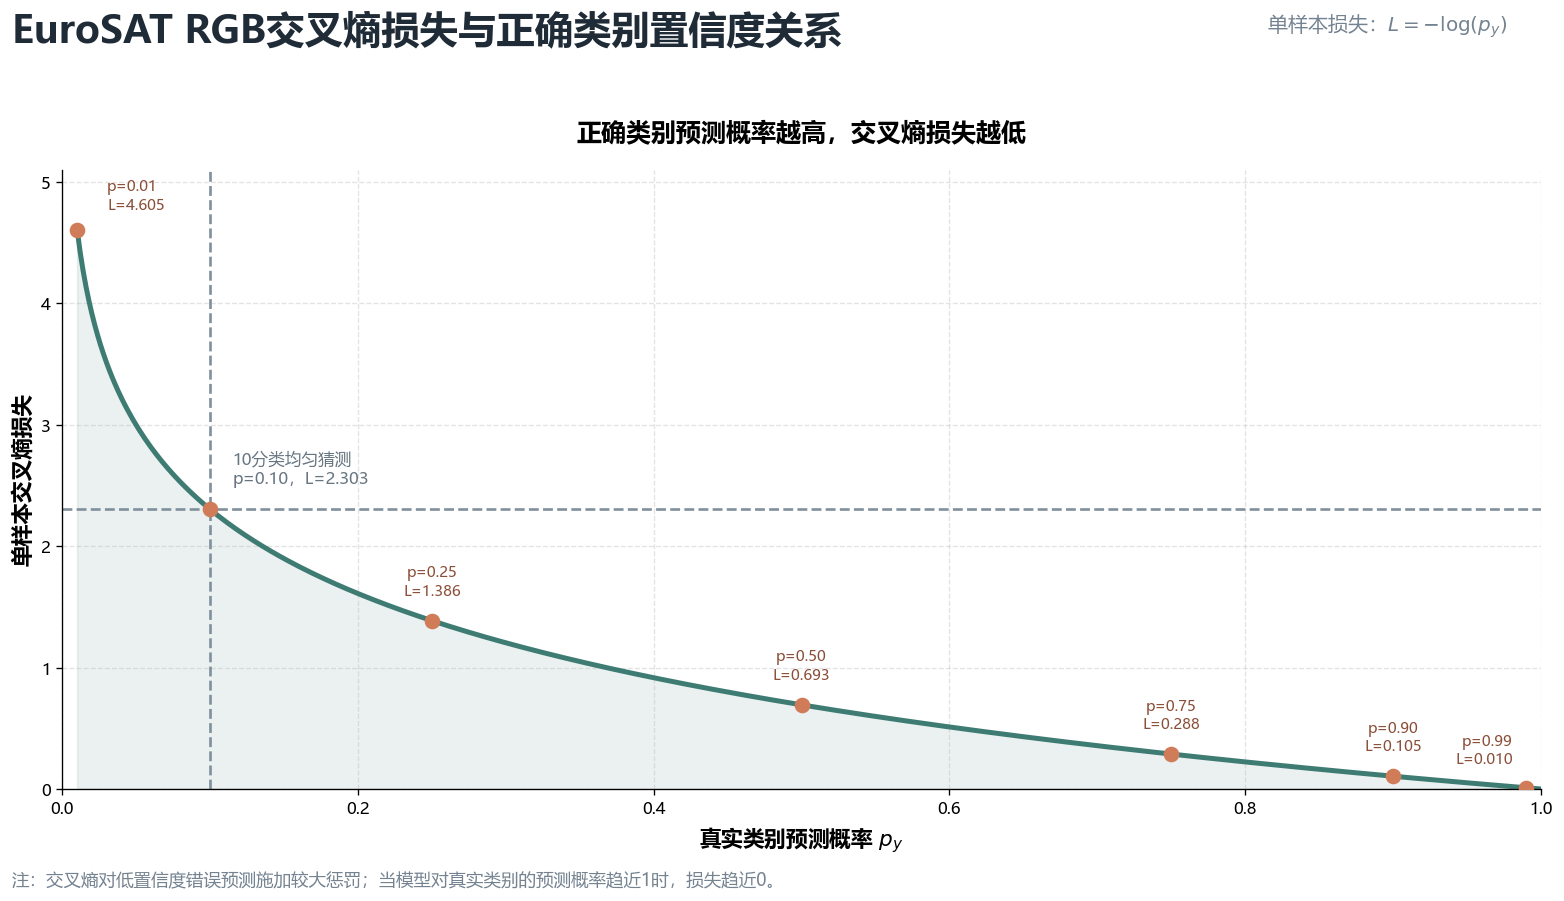

交叉熵响应曲线已保存：09_交叉熵损失响应曲线.png


In [11]:
# ==========================================
# 6.1.2 交叉熵损失响应曲线
# ==========================================

true_class_probabilities = np.linspace(
    0.01,
    0.999,
    500
)

cross_entropy_values = (
    -np.log(
        true_class_probabilities
    )
)


# ------------------------------
# 参考概率点
# ------------------------------
reference_probabilities = np.array([
    0.01,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.99
])

reference_losses = (
    -np.log(
        reference_probabilities
    )
)


# ------------------------------
# 创建画布
# ------------------------------
fig, ax = plt.subplots(
    figsize=(14, 8)
)

# 调整边距，避免标题与图表内容重叠
fig.subplots_adjust(
    left=0.085,
    right=0.965,
    top=0.79,
    bottom=0.145
)


# ------------------------------
# 总标题与公式说明
# ------------------------------
fig.text(
    0.055,
    0.955,
    "EuroSAT RGB交叉熵损失与正确类别置信度关系",
    fontsize=23,
    fontweight="bold",
    color="#1F2B36",
    va="top"
)

fig.text(
    0.945,
    0.955,
    r"单样本损失：$L=-\log(p_y)$",
    fontsize=12,
    color="#748391",
    ha="right",
    va="top"
)


# ------------------------------
# 绘制交叉熵响应曲线
# ------------------------------
ax.plot(
    true_class_probabilities,
    cross_entropy_values,
    linewidth=3,
    color="#3E7C73",
    label="交叉熵损失"
)

ax.fill_between(
    true_class_probabilities,
    cross_entropy_values,
    alpha=0.10,
    color="#3E7C73"
)


# ------------------------------
# 绘制参考点
# ------------------------------
ax.scatter(
    reference_probabilities,
    reference_losses,
    s=70,
    color="#D17C58",
    zorder=4
)


# ------------------------------
# 标注参考点
# p=0.10单独作为均匀猜测参考点标注，
# 避免出现两组重复文字
# ------------------------------
for probability_value, loss_value in zip(
    reference_probabilities,
    reference_losses
):

    if np.isclose(
        probability_value,
        random_guess_probability
    ):
        continue

    if probability_value <= 0.02:

        xytext = (
            18,
            10
        )

        horizontal_alignment = "left"

    elif probability_value >= 0.98:

        xytext = (
            -8,
            12
        )

        horizontal_alignment = "right"

    else:

        xytext = (
            0,
            13
        )

        horizontal_alignment = "center"

    ax.annotate(
        (
            f"p={probability_value:.2f}\n"
            f"L={loss_value:.3f}"
        ),
        xy=(
            probability_value,
            loss_value
        ),
        xytext=xytext,
        textcoords="offset points",
        ha=horizontal_alignment,
        va="bottom",
        fontsize=9,
        color="#8B4E38"
    )


# ------------------------------
# 10分类均匀猜测参考线
# ------------------------------
ax.axvline(
    random_guess_probability,
    linestyle="--",
    linewidth=1.6,
    color="#81909C"
)

ax.axhline(
    random_guess_cross_entropy,
    linestyle="--",
    linewidth=1.6,
    color="#81909C"
)


# 单独标注均匀猜测参考点
ax.text(
    0.115,
    random_guess_cross_entropy + 0.18,
    (
        "10分类均匀猜测\n"
        f"p=0.10，L={random_guess_cross_entropy:.3f}"
    ),
    fontsize=10,
    color="#687682",
    ha="left",
    va="bottom"
)


# ------------------------------
# 坐标轴与标题
# ------------------------------
ax.set_title(
    "正确类别预测概率越高，交叉熵损失越低",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    r"真实类别预测概率 $p_y$",
    fontsize=13
)

ax.set_ylabel(
    "单样本交叉熵损失",
    fontsize=13
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    5.1
)

ax.grid(
    linestyle="--",
    alpha=0.35
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


# ------------------------------
# 底部说明
# ------------------------------
fig.text(
    0.055,
    0.045,
    (
        "注：交叉熵对低置信度错误预测施加较大惩罚；"
        "当模型对真实类别的预测概率趋近1时，损失趋近0。"
    ),
    fontsize=10.5,
    color="#758391"
)


# ------------------------------
# 保存图片
# ------------------------------
loss_curve_path = (
    STEP_OUTPUT_DIR
    / "09_交叉熵损失响应曲线.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(
    f"交叉熵响应曲线已保存："
    f"{loss_curve_path.name}"
)

In [10]:
# ==========================================
# 6.1.2 统一评价配置、完整性检查与文件清单
# ==========================================

# ------------------------------
# 保存后续训练可复用的指标说明
# ------------------------------
evaluation_config = {
    "步骤编号": "6.1.2",
    "步骤名称": "损失函数与评价指标",
    "生成时间": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    ),
    "全局随机种子": GLOBAL_SEED,
    "运行设备": str(
        DEVICE
    ),
    "类别数量": NUM_CLASSES,
    "类别英文顺序": CLASS_NAMES_EN,
    "类别中文顺序": CLASS_NAMES_CN,
    "损失函数": LOSS_FUNCTION_NAME,
    "损失归约方式": LOSS_REDUCTION,
    "标签平滑系数": LABEL_SMOOTHING,
    "是否使用类别权重": USE_CLASS_WEIGHTS,
    "主要评价指标": [
        "交叉熵损失",
        "Top-1 Accuracy",
        "Top-3 Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Balanced Accuracy",
        "Cohen Kappa",
        "Matthews相关系数"
    ],
    "模型选择首要指标": "验证集Macro-F1",
    "模型选择辅助指标": [
        "验证集Accuracy",
        "验证集Loss"
    ],
    "测试集最终输出": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "各类别Precision",
        "各类别Recall",
        "各类别F1",
        "混淆矩阵"
    ],
    "指标完整性检查通过": (
        all_metric_checks_passed
    )
}


evaluation_config_path = (
    STEP_OUTPUT_DIR
    / "10_统一评价配置.json"
)

with open(
    evaluation_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        evaluation_config,
        file,
        ensure_ascii=False,
        indent=4
    )


# ------------------------------
# 必要结果文件检查
# ------------------------------
required_output_files = [
    STEP_OUTPUT_DIR
    / "01_类别标签映射.csv",

    STEP_OUTPUT_DIR
    / "02_损失函数与评价指标配置.json",

    STEP_OUTPUT_DIR
    / "03_交叉熵理论等价性检查.csv",

    STEP_OUTPUT_DIR
    / "04_模拟案例总体指标.csv",

    STEP_OUTPUT_DIR
    / "05_模拟案例类别指标.csv",

    STEP_OUTPUT_DIR
    / "06_部分正确案例混淆矩阵.csv",

    STEP_OUTPUT_DIR
    / "07_评价指标完整性检查.csv",

    STEP_OUTPUT_DIR
    / "08_模拟案例指标与混淆矩阵.png",

    STEP_OUTPUT_DIR
    / "09_交叉熵损失响应曲线.png",

    STEP_OUTPUT_DIR
    / "10_统一评价配置.json"
]


final_integrity_records = [
    {
        "检查项目": "6.1.1统一配置读取",
        "检查结果": (
            f"随机种子{GLOBAL_SEED}，"
            f"设备{DEVICE}"
        ),
        "是否通过": (
            PREVIOUS_CONFIG_PATH.exists()
        )
    },
    {
        "检查项目": "EuroSAT类别数量",
        "检查结果": (
            f"{NUM_CLASSES}类"
        ),
        "是否通过": (
            NUM_CLASSES == 10
        )
    },
    {
        "检查项目": "类别索引连续性",
        "检查结果": (
            "索引0～9"
        ),
        "是否通过": (
            list(
                CLASS_TO_INDEX.values()
            )
            == list(
                range(
                    NUM_CLASSES
                )
            )
        )
    },
    {
        "检查项目": "交叉熵等价性",
        "检查结果": (
            "三种计算结果一致"
        ),
        "是否通过": (
            absolute_difference_manual < 1e-7
            and absolute_difference_nll < 1e-7
        )
    },
    {
        "检查项目": "评价指标完整性",
        "检查结果": (
            f"{metric_integrity_df['是否通过'].sum()}"
            f"/{len(metric_integrity_df)}项通过"
        ),
        "是否通过": (
            all_metric_checks_passed
        )
    },
    {
        "检查项目": "模拟案例数量",
        "检查结果": (
            f"{len(synthetic_cases)}个"
        ),
        "是否通过": (
            len(
                synthetic_cases
            ) == 3
        )
    },
    {
        "检查项目": "必要输出文件",
        "检查结果": (
            f"{sum(path.exists() for path in required_output_files)}"
            f"/{len(required_output_files)}个已生成"
        ),
        "是否通过": all(
            path.exists()
            for path in required_output_files
        )
    }
]


final_integrity_df = pd.DataFrame(
    final_integrity_records
)


final_integrity_path = (
    STEP_OUTPUT_DIR
    / "11_损失函数与评价指标完整性检查.csv"
)

final_integrity_df.to_csv(
    final_integrity_path,
    index=False,
    encoding="utf-8-sig"
)


all_final_checks_passed = bool(
    final_integrity_df[
        "是否通过"
    ].all()
)


print(
    "6.1.2 损失函数与评价指标完整性检查："
)

display(
    final_integrity_df
)


assert all_final_checks_passed, (
    "6.1.2完整性检查未全部通过，"
    "请根据失败项目检查代码。"
)


# ------------------------------
# 输出文件清单
# ------------------------------
manifest_path = (
    STEP_OUTPUT_DIR
    / "12_输出文件清单.csv"
)

manifest_path.touch(
    exist_ok=True
)


output_file_records = []

for output_path in sorted(
    STEP_OUTPUT_DIR.iterdir()
):

    if not output_path.is_file():
        continue

    output_file_records.append({
        "文件名称": output_path.name,
        "文件类型": output_path.suffix.lower(),
        "文件大小_KB": round(
            output_path.stat().st_size
            / 1024,
            2
        ),
        "相对路径": str(
            output_path.relative_to(
                PROJECT_ROOT
            )
        )
    })


output_manifest_df = pd.DataFrame(
    output_file_records
)

output_manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n6.1.2 损失函数与评价指标执行完成。"
)

print(
    f"所有结果均已保存至：\n"
    f"{STEP_OUTPUT_DIR}"
)

print(
    "\n输出文件清单："
)

display(
    output_manifest_df
)

6.1.2 损失函数与评价指标完整性检查：


,检查项目,检查结果,是否通过
0,6.1.1统一配置读取,随机种子42，设备cpu,True
1,EuroSAT类别数量,10类,True
2,类别索引连续性,索引0～9,True
3,交叉熵等价性,三种计算结果一致,True
4,评价指标完整性,9/9项通过,True
5,模拟案例数量,3个,True
6,必要输出文件,10/10个已生成,True



6.1.2 损失函数与评价指标执行完成。
所有结果均已保存至：
d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标

输出文件清单：


,文件名称,文件类型,文件大小_KB,相对路径
0,01_类别标签映射.csv,.csv,0.30,results\06_模型训练与优化\6.1.2_损失函数与评价指标\01_类别标签映射.csv
1,02_损失函数与评价指标配置.json,.json,0.44,results\06_模型训练与优化\6.1.2_损失函数与评价指标\02_损失函数与评价指标配置.json
2,03_交叉熵理论等价性检查.csv,.csv,0.22,results\06_模型训练与优化\6.1.2_损失函数与评价指标\03_交叉熵理论等价性检查.csv
3,04_模拟案例总体指标.csv,.csv,0.55,results\06_模型训练与优化\6.1.2_损失函数与评价指标\04_模拟案例总体指标.csv
4,05_模拟案例类别指标.csv,.csv,1.88,results\06_模型训练与优化\6.1.2_损失函数与评价指标\05_模拟案例类别指标.csv
5,06_部分正确案例混淆矩阵.csv,.csv,0.69,results\06_模型训练与优化\6.1.2_损失函数与评价指标\06_部分正确案例混淆矩阵.csv
6,07_评价指标完整性检查.csv,.csv,0.43,results\06_模型训练与优化\6.1.2_损失函数与评价指标\07_评价指标完整性检查.csv
7,08_模拟案例指标与混淆矩阵.png,.png,618.51,results\06_模型训练与优化\6.1.2_损失函数与评价指标\08_模拟案例指标与混淆矩阵.png
8,09_交叉熵损失响应曲线.png,.png,376.87,results\06_模型训练与优化\6.1.2_损失函数与评价指标\09_交叉熵损失响应曲线.png
9,10_统一评价配置.json,.json,1.60,results\06_模型训练与优化\6.1.2_损失函数与评价指标\10_统一评价配置.json


#### 交叉熵响应关系与本节小结

交叉熵损失响应曲线展示了单样本损失



随真实类别预测概率 `p_y` 的变化关系。当真实类别概率仅为 0.01 时，损失为 4.605，说明模型对真实类别置信度极低时会受到较大的损失惩罚。当概率提高至 0.25、0.50、0.75 和 0.90 时，损失分别下降至约 1.386、0.693、0.288 和 0.105；当概率达到 0.99 时，损失进一步下降至约 0.010。

该曲线说明交叉熵不仅判断预测类别是否正确，还会衡量模型分配给真实类别的置信度。即使两个样本最终都预测正确，对真实类别给出更高概率的样本仍会获得更低的损失。因此，在模型训练过程中，交叉熵能够持续推动模型提高正确类别的预测概率，而不只是改变最终的最大概率类别。

10 分类均匀猜测对应的真实类别概率为 0.10，理论损失为 2.302585。该参考点可以用于观察后续训练过程：若模型初始验证损失接近 2.302585，说明输出近似均匀随机；随着模型学习有效特征，训练损失和验证损失通常应逐渐下降。若损失长期停留在该数值附近，则可能意味着参数未有效更新、学习率设置不合理或数据与标签处理存在问题。

本节最终完整性检查全部通过：

- 成功读取了 6.1.1 保存的统一环境配置，全局随机种子为 42，运行设备为 CPU；
- EuroSAT RGB 类别数量为 10，类别索引连续为 0～9；
- 交叉熵的三种计算方式结果一致；
- 评价指标完整性检查 9 项全部通过；
- 三个确定性模拟案例均成功生成；
- 10 个必要输出文件全部完成保存。

后续训练统一采用平均交叉熵作为优化目标，以验证集 Macro-F1 作为模型选择和最佳权重保存的首要依据，同时参考验证集 Accuracy 与 Loss。最终测试阶段除总体 Accuracy、Macro Precision、Macro Recall 和 Macro-F1 外，还需要输出各类别 Precision、Recall、F1-score 以及混淆矩阵，从而同时评价整体分类性能和不同土地利用类别的识别差异。

需要强调，本节中的三个模拟案例仅用于验证损失函数和指标程序的正确性，并不代表 BaselineCNN 或 ResNet18Transfer 的真实分类性能。正式性能结论必须在后续统一训练完成后，使用独立测试集进行一次性评价。

综上，6.1.2 已完成损失函数、类别映射、评价指标、混淆矩阵和统一评价配置的构建与验证，所有核心检查均符合预期，可以进入下一阶段的训练超参数与优化器配置。